# Section 5.4, Figure 1

Runs the scaling experiment for double-scoring edge-popup approximation and plots empirical error against the theoretical scale.

## Run Notes
- Run the notebook from top to bottom.
- Synthetic function-approximation data only.
- Includes a classical baseline at matched widths.
- Random sampling is intentionally exposed in the experiment cells so readers can vary it.

## Setup

In [1]:
import math
import random

import numpy as np
import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Prefer a GPU in Colab, fall back to Apple MPS when available, and use CPU otherwise.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

class ClassicNetwork(nn.Module):
    """Dense baseline with the same layer sizes as the masked model."""

    def __init__(self, layer_sizes, bias=True):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            *[
                block
                for layer in layer_sizes
                for block in [nn.Linear(layer[0], layer[1], bias=bias), nn.ReLU()]
            ][:-1]
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.linear_relu_stack(x)

def signed_kaiming_constant_(
    tensor,
    a=0,
    mode="fan_in",
    nonlinearity="relu",
    k=0.5,
    sparsity=0,
):
    """Initialize frozen weights with signed Kaiming-style uniform samples."""
    fan = nn.init._calculate_correct_fan(tensor, mode)
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = gain / math.sqrt(fan)

    # The active subnetwork keeps a k-fraction of weights, so rescale by 1/sqrt(k).
    if k != 0:
        std *= 1 / math.sqrt(k)

    with torch.no_grad():
        tensor.uniform_(-std, std)
        if sparsity > 0:
            keep_mask = (torch.rand_like(tensor) > sparsity).float()
            tensor *= keep_mask
        return tensor

class GetSubnet(autograd.Function):
    """Straight-through top-k mask used by edge-popup."""

    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Convert scores to a binary mask by keeping the largest k-fraction.
        out = scores.clone()
        _, idx = scores.flatten().sort()
        cutoff = int((1 - k) * scores.numel())
        flat_out = out.flatten()
        flat_out[idx[:cutoff]] = 0
        flat_out[idx[cutoff:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # Straight-through estimator: pass score gradients through unchanged.
        return grad, None

class LinearSubnet(nn.Linear):
    """Linear layer with frozen weights and trainable scores that choose the mask."""

    def __init__(
        self,
        in_features,
        out_features,
        init=signed_kaiming_constant_,
        k=0.5,
        extra_capacity=0,
        double=True,
        **kwargs,
    ):
        super().__init__(in_features, out_features, **kwargs)
        multiplier = 2 if double else 1
        self.k = k

        # Scores can be wider than the weight matrix; only the realized weight slice is used.
        self.scores = nn.Parameter(
            torch.randn(out_features, multiplier * in_features + extra_capacity)
        )
        init(self.weight)
        self.weight.requires_grad_(False)

        if self.bias is not None:
            self.bias_scores = nn.Parameter(
                torch.randn(multiplier + extra_capacity, out_features)
            )
            self.bias.requires_grad_(False)

    def forward(self, x):
        weight_mask = GetSubnet.apply(self.scores.abs(), self.k)
        weight = self.weight * weight_mask[:, : self.weight.shape[-1]]

        if self.bias is None:
            return F.linear(x, weight)

        bias_mask = GetSubnet.apply(self.bias_scores.abs(), self.k)
        bias = self.bias * bias_mask[1, : self.bias.shape[-1]]
        return F.linear(x, weight, bias)


class Network(nn.Module):
    """Small MLP assembled from masked LinearSubnet layers."""

    def __init__(
        self,
        layer_sizes,
        init=signed_kaiming_constant_,
        bias=True,
        double=True,
        extra_capacity=0,
    ):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            *[
                block
                for layer in layer_sizes
                for block in [
                    LinearSubnet(
                        layer[0],
                        layer[1],
                        init=init,
                        bias=bias,
                        double=double,
                        extra_capacity=extra_capacity,
                    ),
                    nn.ReLU(),
                ]
            ][:-1]
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

Using cuda device


## Experiment and Figure

Epsilon target: 0.100
  Extra width: 0   masked hidden width: 1
    n=    6, m=    6, eps_target=0.1000, eps_theory=5.0000e-01, eps_ach=6.5479e-01 ± 1.24e-01, ratio=1.310
  Extra width: 1   masked hidden width: 3
    n=   13, m=   22, eps_target=0.1000, eps_theory=3.0943e-01, eps_ach=5.9623e-01 ± 5.97e-01, ratio=1.927
  Extra width: 2   masked hidden width: 5
    n=   22, m=   46, eps_target=0.1000, eps_theory=2.3473e-01, eps_ach=3.2975e-01 ± 1.80e-01, ratio=1.405
  Extra width: 3   masked hidden width: 7
    n=   33, m=   78, eps_target=0.1000, eps_theory=1.9430e-01, eps_ach=2.0415e-01 ± 9.04e-02, ratio=1.051
  Extra width: 4   masked hidden width: 9
    n=   46, m=  118, eps_target=0.1000, eps_theory=1.6896e-01, eps_ach=1.2220e-01 ± 1.10e-01, ratio=0.723
  Extra width: 5   masked hidden width: 11
    n=   61, m=  166, eps_target=0.1000, eps_theory=1.5164e-01, eps_ach=1.2210e-01 ± 7.23e-02, ratio=0.805
  Extra width: 6   masked hidden width: 13
    n=   78, m=  222, eps_target=0.1000,

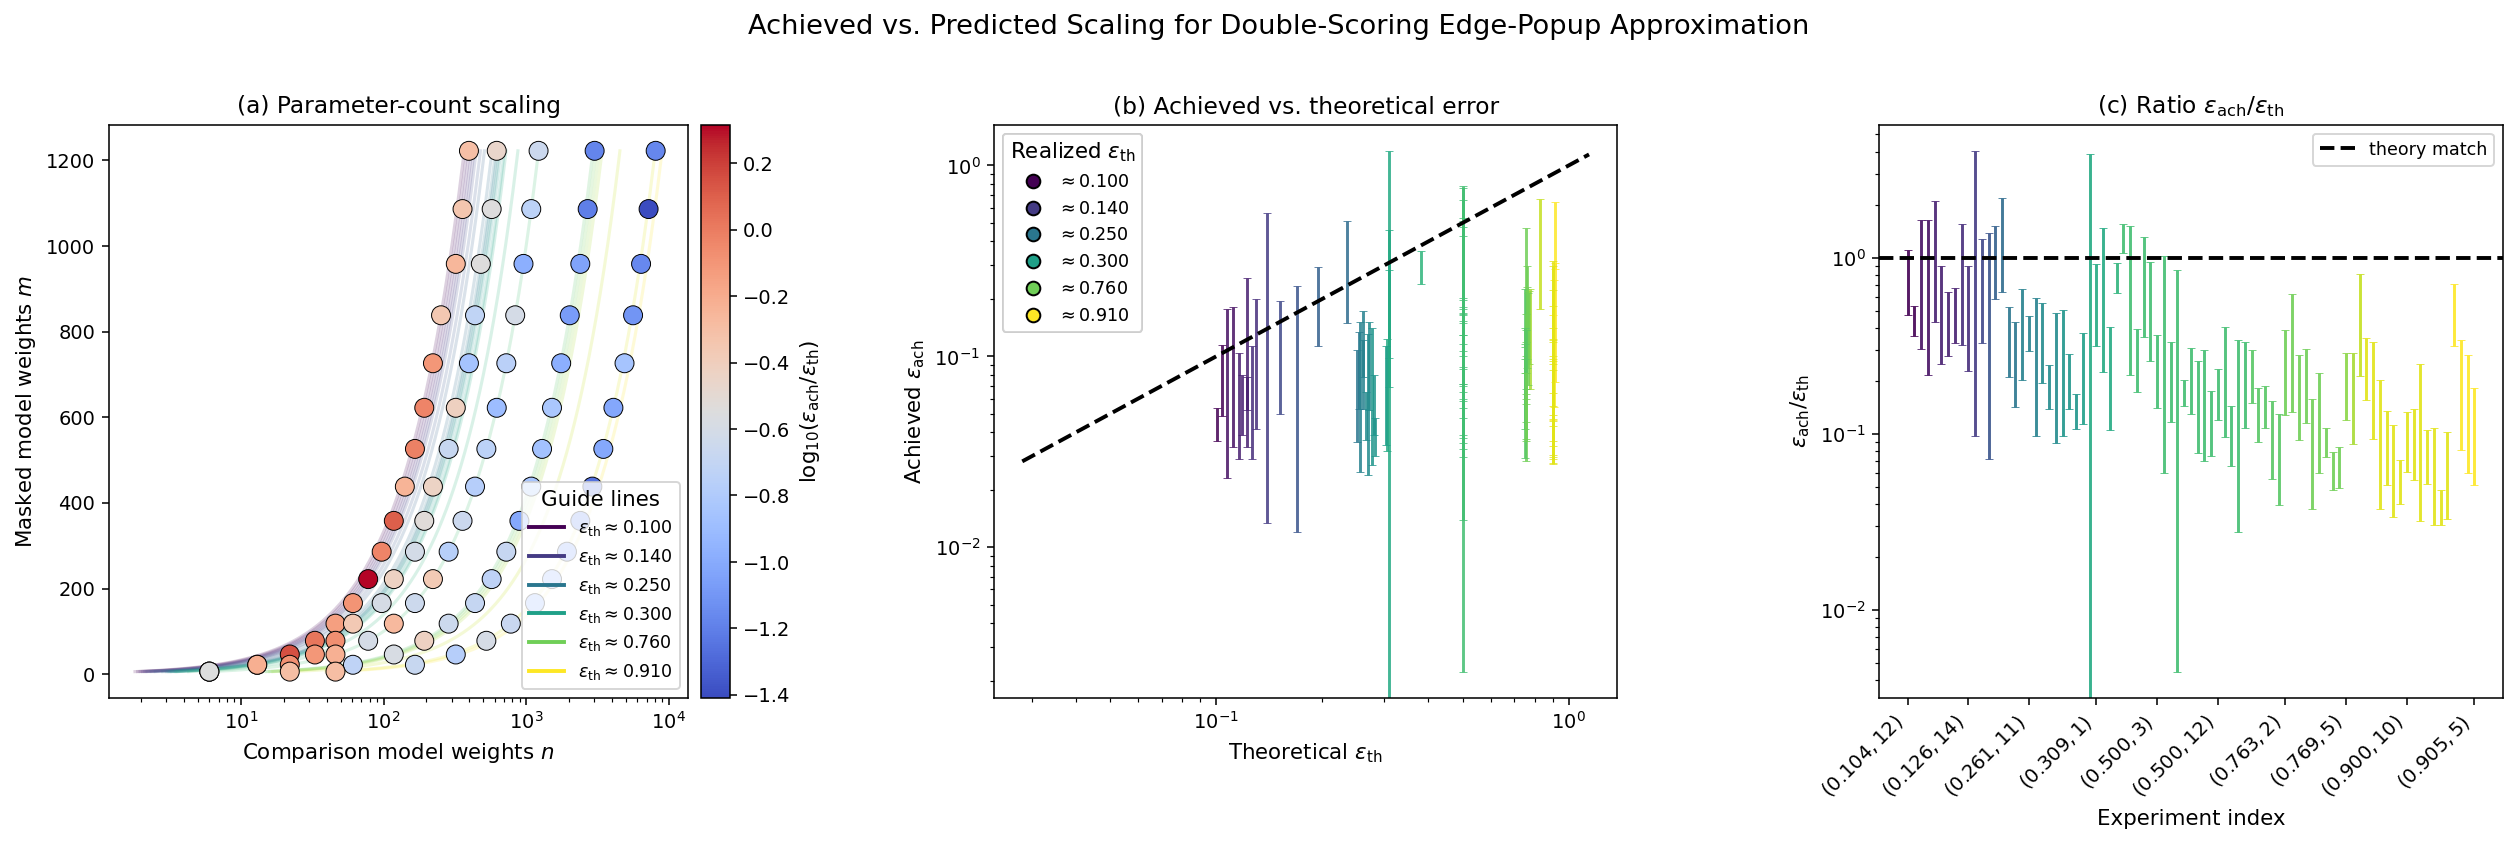

In [2]:
# Experiment outline:
# 1. Sweep target approximation errors and hidden-width settings.
# 2. Train masked models and matched classical baselines.
# 3. Compare achieved error with the theoretical epsilon scale in one paper figure.

# ============================================================
# Scaling experiment: single paper-quality 3-panel figure
# corrected so that all plotting/grouping uses REALIZED
# theoretical epsilons epsilon_th = 2^(-m/n), not just targets
# ============================================================


# -----------------------------
# Reproducibility
# -----------------------------
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# -----------------------------
# User-facing experiment knobs
# -----------------------------
NUM_EPOCHS = 100
width_initial = 1
max_added_width = 16
epsilon_values = [0.1, 0.25, 0.5, 0.75, 0.9]   # nominal targets only
repeats = 5
batch_size = 512
train_samples = 4096
test_samples = 512

# how tightly to cluster realized epsilons for display/legend purposes
# (this avoids tiny floating point differences producing too many groups)
REALIZED_EPS_ROUND_DECIMALS = 2

# ------------------------------------------------------------
# Helper: sample inputs on a box
# ------------------------------------------------------------
def sample_inputs(num_points, dim, device='cpu', low=-1.0, high=1.0):
    return (high - low) * torch.rand(num_points, dim, device=device) + low

# ------------------------------------------------------------
# Helper: train masked model to imitate comparison model
# ------------------------------------------------------------
def trainit(model,
            optimizer,
            comparison_model,
            width_initial,
            NUM_EPOCHS=20,
            batch_size=32,
            train_size=4096,
            input_low=-1.0,
            input_high=1.0,
            return_losses=False,
            device='cpu'):
    """
    Train `model` to mimic `comparison_model` on randomly sampled inputs.
    """
    model.train()
    comparison_model.eval()

    losses = []
    steps_per_epoch = max(1, train_size // batch_size)

    for epoch in range(NUM_EPOCHS):
        epoch_loss = 0.0

        for _ in range(steps_per_epoch):
            x = sample_inputs(batch_size, width_initial, device=device,
                              low=input_low, high=input_high)

            with torch.no_grad():
                y_target = comparison_model(x)

            optimizer.zero_grad()
            y_pred = model(x)
            loss = torch.max(F.mse_loss(y_pred, y_target))
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= steps_per_epoch
        losses.append(epoch_loss)

    if return_losses:
        return losses

# ------------------------------------------------------------
# Helper: max loss on a held-out random test set
# ------------------------------------------------------------
def test_max_loss(model,
                  comparison_model,
                  width_initial,
                  test_size=2048,
                  batch_size=512,
                  input_low=-1.0,
                  input_high=1.0,
                  device='cpu'):
    """
    Returns max pointwise squared error over a random test set:
        max_i ||f(x_i) - g(x_i)||_2^2
    """
    model.eval()
    comparison_model.eval()

    max_err = 0.0

    with torch.no_grad():
        remaining = test_size
        while remaining > 0:
            b = min(batch_size, remaining)
            x = sample_inputs(b, width_initial, device=device,
                              low=input_low, high=input_high)

            y_true = comparison_model(x)
            y_pred = model(x)

            pointwise_sq_err = torch.sqrt(torch.sum((y_pred - y_true) ** 2, dim=1))
            batch_max = pointwise_sq_err.max().item()
            max_err = max(max_err, batch_max)

            remaining -= b

    return max_err

# ------------------------------------------------------------
# Parameter count helpers
# ------------------------------------------------------------
def frozen_parameter_count(model):
    return sum(p.numel() for p in model.parameters() if not p.requires_grad)

def trainable_parameter_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ------------------------------------------------------------
# Utilities for realized theoretical epsilon
# ------------------------------------------------------------
def eps_key(eps, decimals=REALIZED_EPS_ROUND_DECIMALS):
    return round(float(eps), decimals)

def fmt_eps(eps, digits=3):
    return f"{float(eps):.{digits}f}"

# ------------------------------------------------------------
# Run experiment
# ------------------------------------------------------------
outcomes = []

for epsilon_target in epsilon_values:
    print(f"Epsilon target: {epsilon_target:.3f}")

    for extra_width in range(0, max_added_width + 1):
        width = width_initial + 2 * extra_width
        print(f"  Extra width: {extra_width}   masked hidden width: {width}")

        epsilon_achieved_vals = []

        for r in range(repeats):
            model = Network(
                [[width_initial, width], [width, width], [width, width_initial]]
            )
            model.to(device)

            # m = frozen parameter count in masked model
            m = frozen_parameter_count(model)

            # choose comparison model so n is approximately m/log2(1/epsilon_target)
            comparison_desired_total = math.ceil(m / math.log2(1 / epsilon_target))

            width_small = math.ceil(
                math.sqrt(width_initial**2 + width_initial + comparison_desired_total + 1)
                - width_initial - 1
            )
            width_small = max(1, width_small)

            comparison_model = ClassicNetwork(
                [[width_initial, width_small],
                 [width_small, width_small],
                 [width_small, width_initial]]
            )
            comparison_model.to(device)

            # n = trainable parameter count in comparison model
            n = trainable_parameter_count(comparison_model)

            # REALIZED theoretical epsilon from integer parameter counts
            epsilon_theoretical = 2 ** (-m / n)

            optimizer = optim.Adam(model.parameters())

            # uniform training budget throughout
            trainit(
                model,
                optimizer,
                comparison_model,
                width_initial,
                NUM_EPOCHS=NUM_EPOCHS,
                batch_size=batch_size,
                train_size=train_samples,
                return_losses=True,
                device=device
            )

            epsilon_test = test_max_loss(
                model,
                comparison_model,
                width_initial,
                test_size=test_samples,
                device=device
            )

            epsilon_achieved_vals.append(epsilon_test)

        epsilon_achieved_mean = float(np.mean(epsilon_achieved_vals))
        epsilon_achieved_std = float(np.std(epsilon_achieved_vals))
        epsilon_theoretical_key = eps_key(epsilon_theoretical)

        outcomes.append({
            "epsilon_target": float(epsilon_target),            # nominal target
            "epsilon_theoretical": float(epsilon_theoretical),  # realized theory value
            "epsilon_theoretical_key": epsilon_theoretical_key, # grouped realized value
            "extra_width": int(extra_width),
            "masked_width": int(width),
            "comparison_width": int(width_small),
            "n": int(n),
            "m": int(m),
            "epsilon_achieved_mean": epsilon_achieved_mean,
            "epsilon_achieved_std": epsilon_achieved_std,
            "ratio": epsilon_achieved_mean / epsilon_theoretical,
        })

        print(
            f"    n={n:5d}, m={m:5d}, "
            f"eps_target={epsilon_target:.4f}, "
            f"eps_theory={epsilon_theoretical:.4e}, "
            f"eps_ach={epsilon_achieved_mean:.4e} ± {epsilon_achieved_std:.2e}, "
            f"ratio={epsilon_achieved_mean / epsilon_theoretical:.3f}"
        )

# ------------------------------------------------------------
# Convert to arrays
# ------------------------------------------------------------
eps_theory = np.array([o["epsilon_theoretical"] for o in outcomes], dtype=float)
eps_theory_keys = np.array([o["epsilon_theoretical_key"] for o in outcomes], dtype=float)
n_vals = np.array([o["n"] for o in outcomes], dtype=float)
m_vals = np.array([o["m"] for o in outcomes], dtype=float)
eps_ach = np.array([o["epsilon_achieved_mean"] for o in outcomes], dtype=float)
ratios = np.array([o["ratio"] for o in outcomes], dtype=float)

# distinct realized-theory values actually present in the data
realized_eps_unique = sorted(set(float(x) for x in eps_theory_keys))

# ------------------------------------------------------------
# Paper-quality style
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 140,
})

# ------------------------------------------------------------
# Visual encodings
#   - color = realized theoretical epsilon
#   - marker = extra width
# This keeps the whole figure aligned with realized theory values.
# ------------------------------------------------------------

# color by realized epsilon group
eps_to_color = {
    eps: plt.cm.viridis(i / max(1, len(realized_eps_unique) - 1))
    for i, eps in enumerate(realized_eps_unique)
}

# ------------------------------------------------------------
# Single 3-panel figure
# layout-fixed version
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(19, 6.6))
fig.subplots_adjust(left=0.06, right=0.96, bottom=0.24, top=0.86, wspace=0.42)

# To avoid enormous legends, only show a subset of realized epsilon labels
max_eps_labels = 6
if len(realized_eps_unique) <= max_eps_labels:
    realized_eps_for_legend = realized_eps_unique
else:
    idxs = np.linspace(0, len(realized_eps_unique) - 1, max_eps_labels, dtype=int)
    realized_eps_for_legend = [realized_eps_unique[i] for i in idxs]

# =========================
# Panel 1: (n, m)-plane
# use realized theoretical epsilons for guide lines
# =========================
ax = axes[0]

m_min = int(m_vals.min())
m_max = int(m_vals.max())
m_line = np.linspace(m_min, m_max, 400)

for eps_real in realized_eps_unique:
    x_line = m_line / math.log2(1 / eps_real)
    ax.plot(
        x_line,
        m_line,
        linewidth=1.6,
        alpha=0.18,
        color=eps_to_color[eps_real]
    )

sc1 = ax.scatter(
    n_vals,
    m_vals,
    c=np.log10(ratios),
    cmap="coolwarm",
    s=95,
    edgecolors="black",
    linewidths=0.5,
    zorder=3
)

cbar1 = fig.colorbar(sc1, ax=ax, fraction=0.05, pad=0.02)
cbar1.set_label(r"$\log_{10}\!\left(\varepsilon_{\rm ach}/\varepsilon_{\rm th}\right)$")

# Smaller representative legend for realized epsilon guide lines
eps_line_handles = [
    Line2D([0], [0], color=eps_to_color[eps], linewidth=2,
           label=rf"$\varepsilon_{{\rm th}}\approx {fmt_eps(eps)}$")
    for eps in realized_eps_for_legend
]
ax.legend(handles=eps_line_handles, loc="lower right", frameon=True, title="Guide lines")

ax.set_title("(a) Parameter-count scaling")
ax.set_xlabel(r"Comparison model weights $n$")
ax.set_ylabel(r"Masked model weights $m$")
ax.set_xscale("log")

# =========================
# Panel 2: achieved vs theoretical error
# =========================
ax = axes[1]

for o in outcomes:
    ax.errorbar(
        o["epsilon_theoretical"],
        o["epsilon_achieved_mean"],
        yerr=o["epsilon_achieved_std"],
        color=eps_to_color[o["epsilon_theoretical_key"]],
        markeredgecolor="black",
        markeredgewidth=0.45,
        markersize=7,
        capsize=2,
        alpha=0.85
    )

lo = min(eps_theory.min(), eps_ach.min())
hi = max(eps_theory.max(), eps_ach.max())
grid = np.logspace(np.log10(lo * 0.8), np.log10(hi * 1.25), 300)
ax.plot(grid, grid, linestyle="--", linewidth=2, color="black")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("(b) Achieved vs. theoretical error")
ax.set_xlabel(r"Theoretical $\varepsilon_{\rm th}$")
ax.set_ylabel(r"Achieved $\varepsilon_{\rm ach}$")

# More compact legends
eps_handles = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=eps_to_color[eps], markeredgecolor='black',
           markersize=7, label=rf"$\approx {fmt_eps(eps)}$")
    for eps in realized_eps_for_legend
]


leg1 = ax.legend(
    handles=eps_handles,
    loc="upper left",
    frameon=True,
    title=r"Realized $\varepsilon_{\rm th}$",
    borderpad=0.4,
    handletextpad=0.4
)
ax.add_artist(leg1)


# =========================
# Panel 3: ratio plot
# =========================
ax = axes[2]

sorted_outcomes = sorted(
    outcomes,
    key=lambda o: (o["epsilon_theoretical_key"], o["extra_width"], o["n"], o["m"])
)


for i, o in enumerate(sorted_outcomes):
    ratio_std = o["epsilon_achieved_std"] / o["epsilon_theoretical"] if o["epsilon_theoretical"] > 0 else 0.0
    ax.errorbar(
        i,
        o["ratio"],
        yerr=ratio_std,
        color=eps_to_color[o["epsilon_theoretical_key"]],
        markeredgecolor="black",
        markeredgewidth=0.45,
        markersize=7,
        capsize=2,
        alpha=0.9
    )

ax.axhline(1.0, linestyle="--", linewidth=2, color="black", label="theory match")
ax.set_yscale("log")
ax.set_title(r"(c) Ratio $\varepsilon_{\rm ach}/\varepsilon_{\rm th}$")
ax.set_xlabel("Experiment index")
ax.set_ylabel(r"$\varepsilon_{\rm ach}/\varepsilon_{\rm th}$")

# Thin the tick labels so they do not destroy the layout
max_xticks = 10
if len(sorted_outcomes) <= max_xticks:
    tick_idx = np.arange(len(sorted_outcomes))
else:
    tick_idx = np.linspace(0, len(sorted_outcomes) - 1, max_xticks, dtype=int)

tick_labels = [
    rf"$({fmt_eps(sorted_outcomes[i]['epsilon_theoretical'])},{sorted_outcomes[i]['extra_width']})$"
    for i in tick_idx
]
ax.set_xticks(tick_idx)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")

ax.legend(loc="upper right", frameon=True)

# overall title
fig.suptitle(
    "Achieved vs. Predicted Scaling for Double-Scoring Edge-Popup Approximation",
    fontsize=14
)

plt.show()